# Preprocessing and clustering

In [2]:
# Core scverse libraries
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
first_run = False
preprocessed = True

if first_run:
    
    from pathlib import Path
    import pandas as pd
    from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
    from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data
    merfish_genes = pd.read_csv('../data/Xenium_V1_FF_Mouse_Brain_MultiSection_Input_gene_groups.csv')
    merfish_genes.index = merfish_genes.index.str.replace('Hs3St2', 'Hs3st2')

    download_base = Path('../data/ABA_WMB_atlas')
    abc_cache = AbcProjectCache.from_cache_dir(download_base)
    abc_cache.load_manifest('releases/20241130/manifest.json')

    cell = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='cell_metadata').set_index('cell_label')
    cell = cell[cell.dataset_label.str.startswith('WMB-10Xv')]

    gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene').set_index('gene_identifier')
    
    gene_data = pd.read_parquet('../data/WMB-10X_subset_merfish_genes.parquet')
    # Create anndata
    adata = ad.AnnData(
        X=gene_data,
        obs=cell,
        var=gene[gene.gene_symbol.isin(merfish_genes.index)].set_index('gene_symbol')
    )

    del adata.var['comment']
    
    # Download cluster annotation from
    # https://allen-brain-cell-atlas.s3.us-west-2.amazonaws.com/index.html#metadata/WMB-10X/20241115/
    cell_meta = pd.read_csv("../data/ABA_WMB_atlas/metadata/WMB-10X/20241115/cell_metadata_with_cluster_annotation.csv").set_index('cell_label')
    # Only keep columns that are not in adata.obs
    cell_meta = cell_meta[cell_meta.columns.difference(adata.obs.columns)]
    
    # Lft join adata.obs with cell_meta
    adata.obs = adata.obs.join(cell_meta, how='left')
    
    adata.write_h5ad('../data/WMB-10X_subset_merfish_genes.h5ad')

if not preprocessed:    
    adata = sc.read_h5ad('../data/WMB-10X_subset_merfish_genes.h5ad')
elif preprocessed:
    adata = sc.read_h5ad('../data/WMB-10X_subset_merfish_genes_processed.h5ad')


In [3]:
def plot_umap(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None):

    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    
    if cmap is not None :
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None :
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    ax.axis('equal')
    ax.set_xlim(-18, 27)
    ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    return fig, ax

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


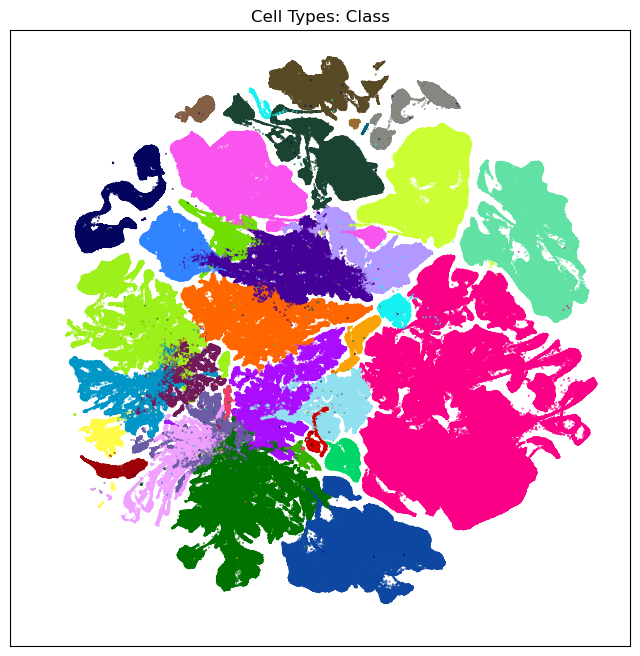

In [46]:
fig, ax = plot_umap(adata.obs['x'], adata.obs['y'], cc=adata.obs['class_color'])
res = ax.set_title("Cell Types: Class")
plt.show()

## Quality Control

In [25]:
sc.pp.calculate_qc_metrics(
    adata, inplace=True, log1p=True, percent_top=[10]
)

/home/chananchidas/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/preprocessing/_qc.py:432: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


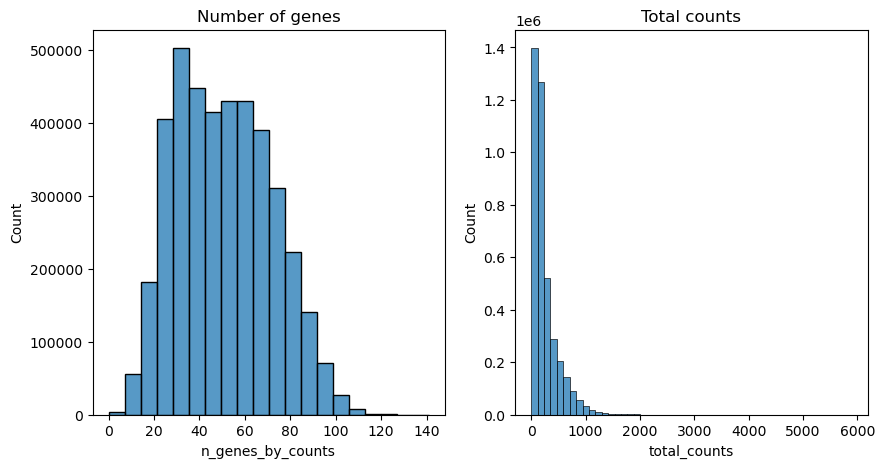

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["n_genes_by_counts"], bins=20, kde=False, ax=axes[0])
axes[0].set_title("Number of genes")
p2 = sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Total counts")
plt.show()

In [31]:
sc.pp.filter_cells(adata, min_counts=1)

## Normalization

The next preprocessing step is normalization. A common approach is count depth scaling with subsequent log plus one (log1p) transformation. Count depth scaling normalizes the data to a “size factor” such as the median count depth in the dataset, ten thousand (CP10k) or one million (CPM, counts per million). The size factor for count depth scaling can be controlled via `target_sum` in `pp.normalize_total`. We are applying median count depth normalization with log1p transformation (AKA log1PF).

In [32]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [33]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [34]:
adata.obs["log1p_counts_norm"] = adata.X.sum(axis=1)

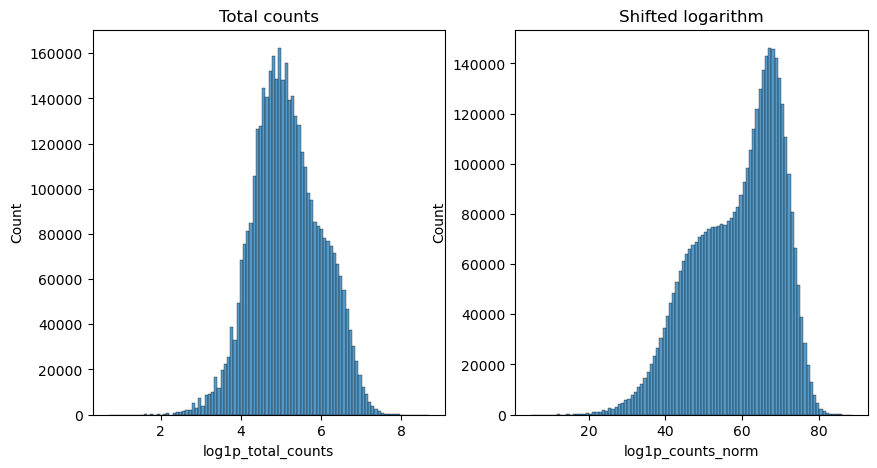

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.obs["log1p_counts_norm"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Differentially-expressed Genes as Markers

In [ ]:
# Obtain class-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="class", method="wilcoxon")

We can then visualize the top 5 differentially-expressed genes on a dotplot.

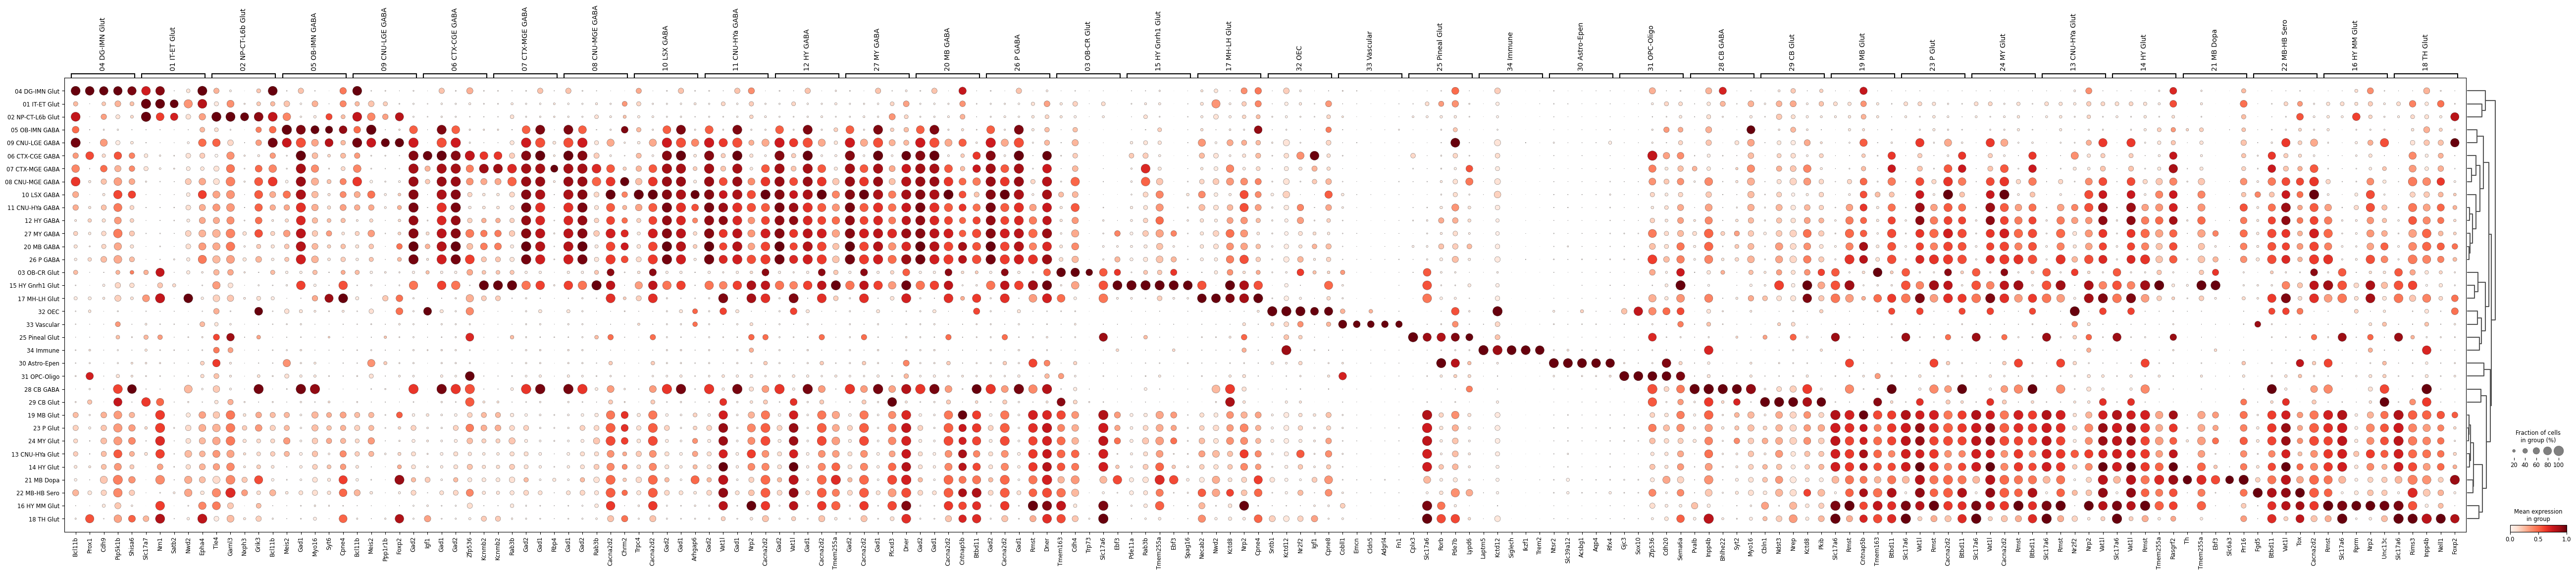

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="class", standard_scale="var", n_genes=5,
    save="marker_genes_class.png"
)

### Plot select marker genes

In [38]:
# Add adata.obsm['X_umap] for easier plotting
adata.obsm['X_umap'] = np.array(adata.obs[['x', 'y']])

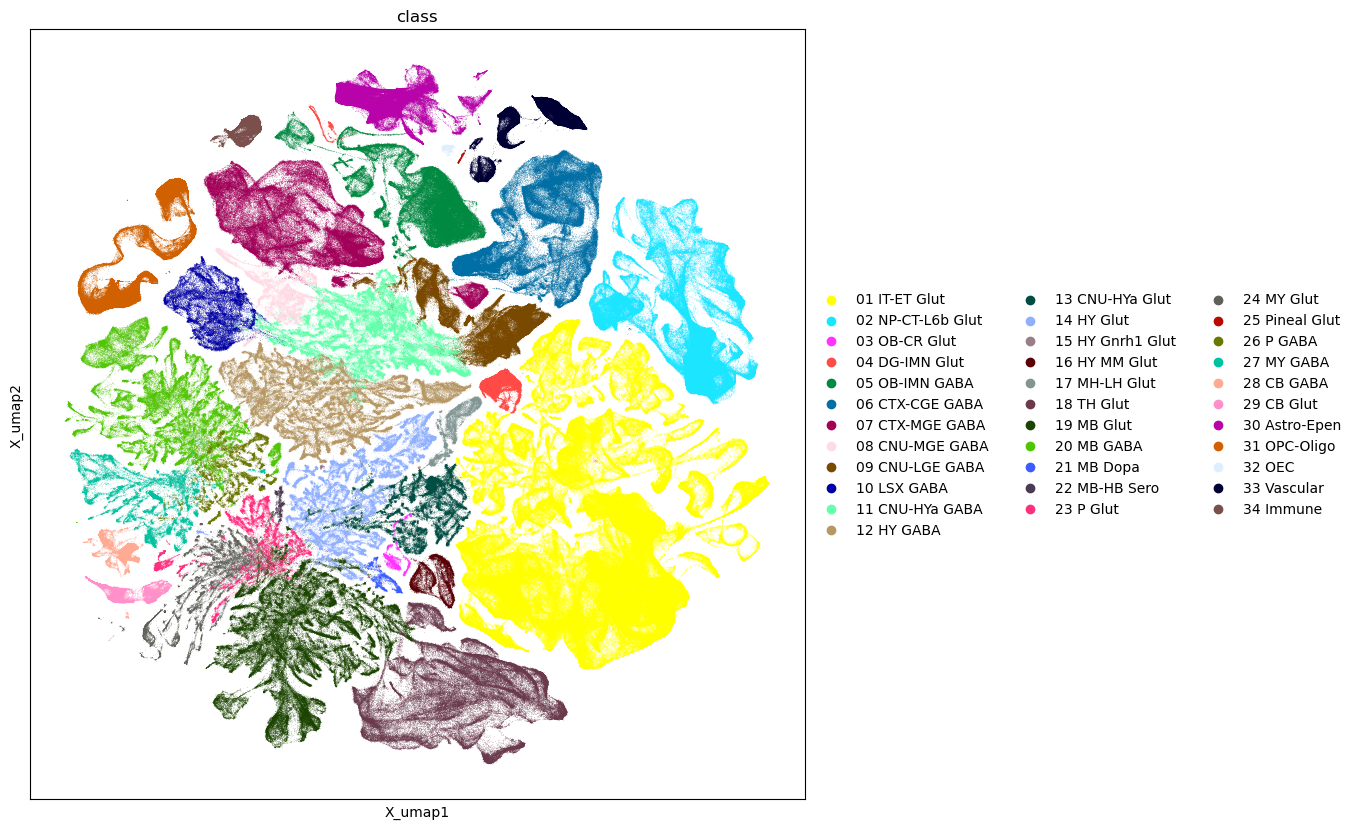

In [39]:
# Sanity check?
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sc.pl.embedding(adata, basis='X_umap', color='class', s=0.5, ax=ax)

In [41]:
adata.obs['class'].cat.categories

Index(['01 IT-ET Glut', '02 NP-CT-L6b Glut', '03 OB-CR Glut', '04 DG-IMN Glut',
       '05 OB-IMN GABA', '06 CTX-CGE GABA', '07 CTX-MGE GABA',
       '08 CNU-MGE GABA', '09 CNU-LGE GABA', '10 LSX GABA', '11 CNU-HYa GABA',
       '12 HY GABA', '13 CNU-HYa Glut', '14 HY Glut', '15 HY Gnrh1 Glut',
       '16 HY MM Glut', '17 MH-LH Glut', '18 TH Glut', '19 MB Glut',
       '20 MB GABA', '21 MB Dopa', '22 MB-HB Sero', '23 P Glut', '24 MY Glut',
       '25 Pineal Glut', '26 P GABA', '27 MY GABA', '28 CB GABA', '29 CB Glut',
       '30 Astro-Epen', '31 OPC-Oligo', '32 OEC', '33 Vascular', '34 Immune'],
      dtype='object')

In [42]:
sc.get.rank_genes_groups_df(adata, group='01 IT-ET Glut')

,names,scores,logfoldchanges,pvals,pvals_adj
0,Slc17a7,1296.635620,3.853243,0.0,0.0
1,Nrn1,1208.566650,3.291140,0.0,0.0
2,Satb2,1139.184937,4.261931,0.0,0.0
3,Nwd2,1084.258423,3.200012,0.0,0.0
4,Epha4,1072.806763,2.526683,0.0,0.0
...,...,...,...,...,...
243,Cacna2d2,-465.819214,-2.986053,0.0,0.0
244,Gad2,-481.109497,-4.235270,0.0,0.0
245,Tle4,-487.030731,-1.784516,0.0,0.0
246,Gad1,-490.182068,-3.833711,0.0,0.0


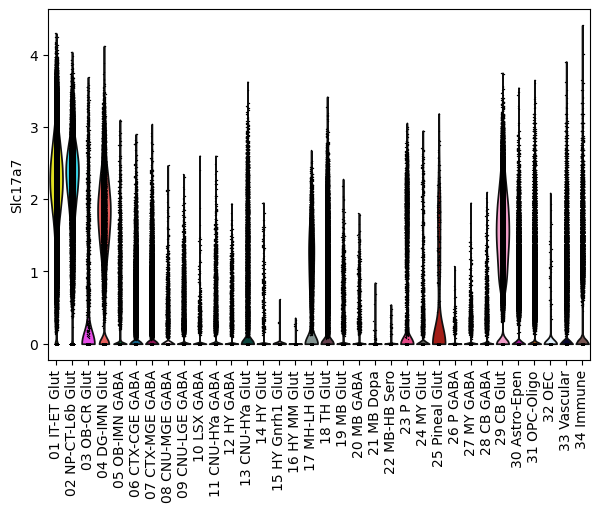

In [43]:
sc.pl.violin(adata, keys='Slc17a7', groupby='class', rotation=90, stripplot=True)

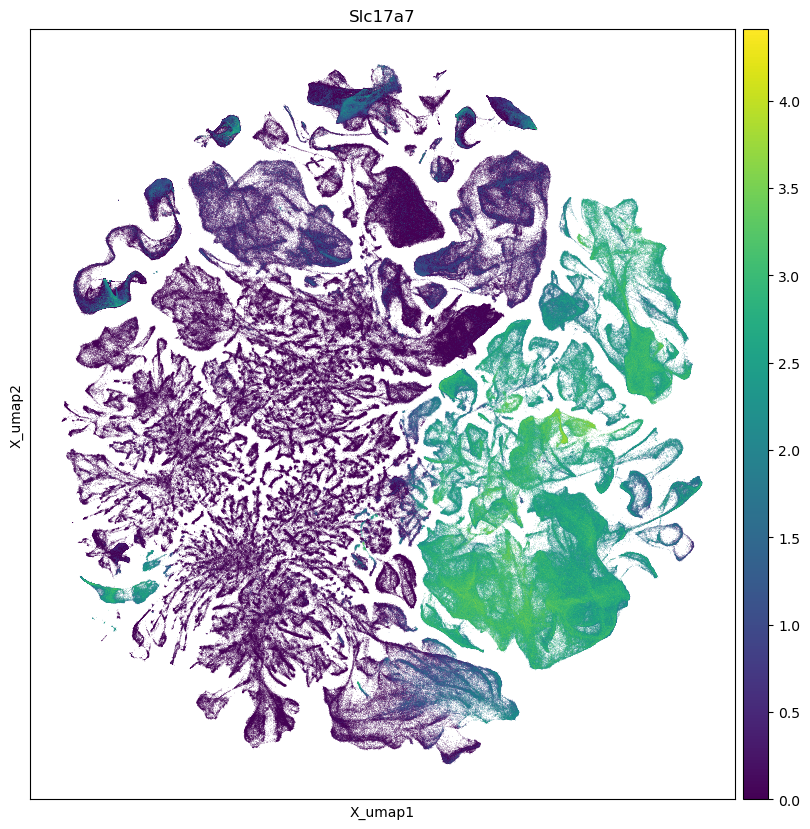

(np.float64(-15.87106305),
 np.float64(26.51834005),
 np.float64(-16.73651985),
 np.float64(26.883074850000003))

In [44]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sc.pl.embedding(adata, basis='X_umap', color='Slc17a7', s=0.5, ax=ax)
ax.axis('equal')

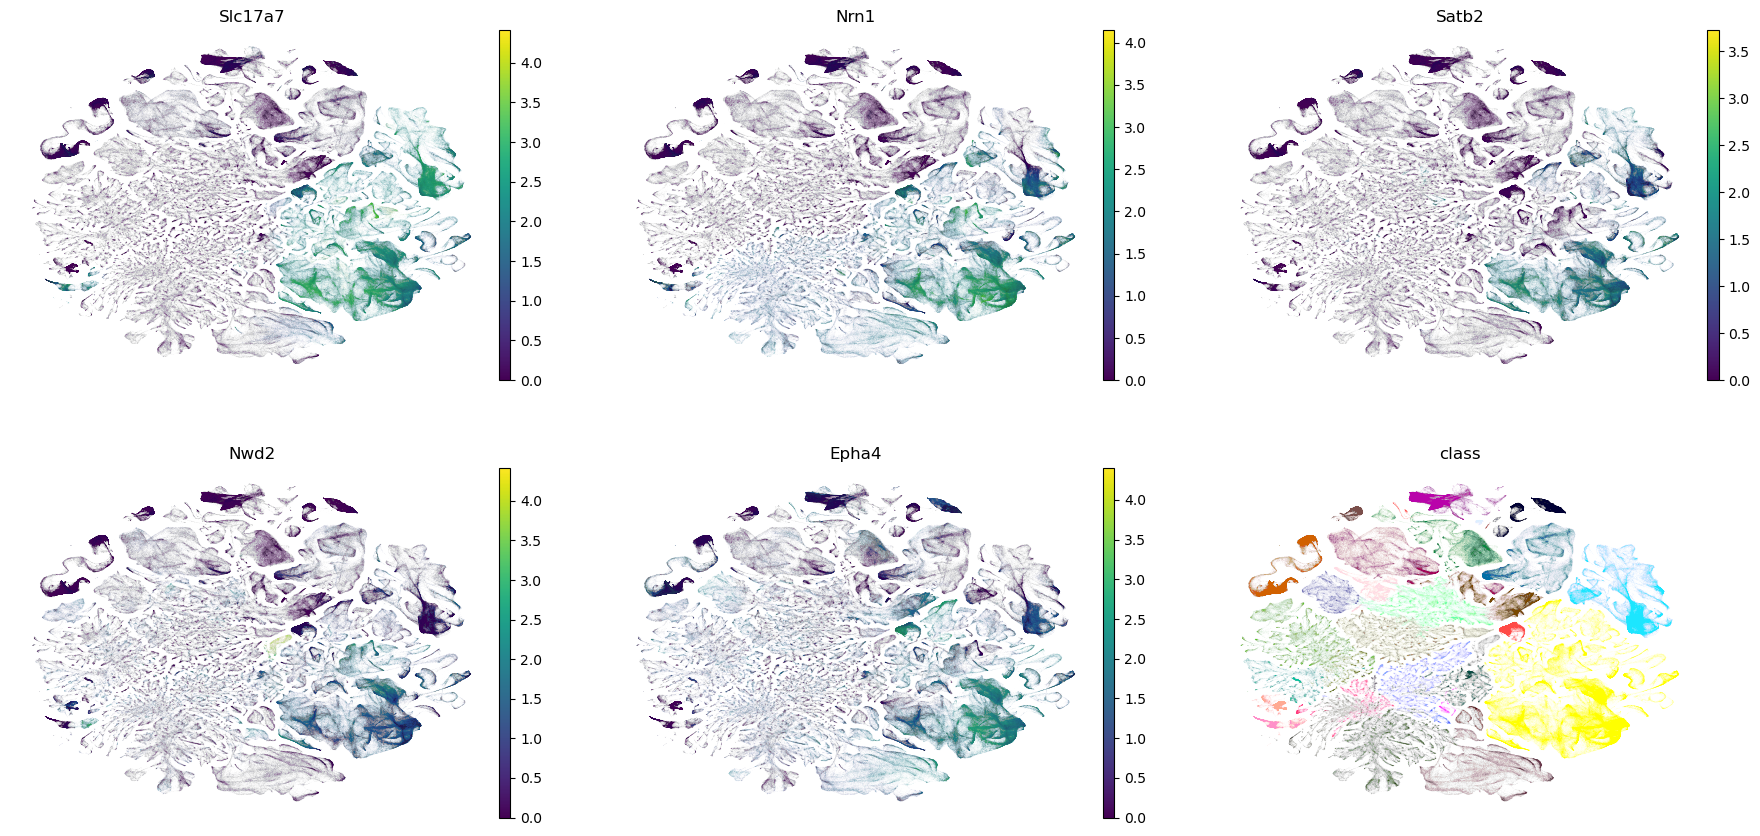

In [45]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="01 IT-ET Glut").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "class"],
    legend_loc="none",
    frameon=False,
    ncols=3,
)

In [ ]:
# Save preprocessed data
adata.write('../data/WMB-10X_subset_merfish_genes_processed.h5ad')

You may have noticed that the p-values found here are extremely low. This is due to the statistical test being performed considering each cell as an independent sample. For a more conservative approach you may want to consider "pseudo-bulking" your data by sample (*e.g.* `sc.get.aggregate(adata, by=["sample", "cell_type"], func="sum", layer="counts")`) and using a more powerful differential expression tool, like [`pydeseq2`](https://pydeseq2.readthedocs.io/).

### Export marker genes

In [10]:
sc.get.rank_genes_groups_df(adata, group=None)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,01 IT-ET Glut,Slc17a7,1296.635620,3.853243,0.0,0.0
1,01 IT-ET Glut,Nrn1,1208.566650,3.291140,0.0,0.0
2,01 IT-ET Glut,Satb2,1139.184937,4.261931,0.0,0.0
3,01 IT-ET Glut,Nwd2,1084.258423,3.200012,0.0,0.0
4,01 IT-ET Glut,Epha4,1072.806763,2.526683,0.0,0.0
...,...,...,...,...,...,...
8427,34 Immune,Mapk4,-241.308762,-4.375723,0.0,0.0
8428,34 Immune,Tmem132d,-244.560684,-4.749518,0.0,0.0
8429,34 Immune,Dner,-253.380219,-3.435155,0.0,0.0
8430,34 Immune,Sorcs3,-258.347107,-4.406861,0.0,0.0


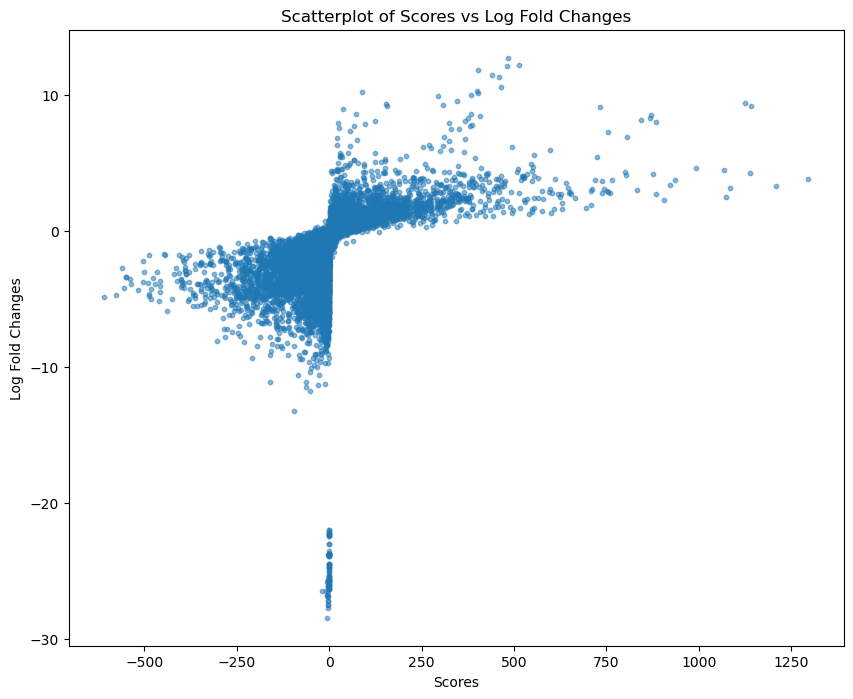

In [ ]:
# How do the scores and LFC relate to each other?
rank_genes_df = sc.get.rank_genes_groups_df(adata, group=None)

# Create a scatter plot
fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
ax.scatter(rank_genes_df['scores'], rank_genes_df['logfoldchanges'], s=10, alpha=0.5)
ax.set_xlabel('Scores')
ax.set_ylabel('Log Fold Changes')
ax.set_title('Scatterplot of Scores vs Log Fold Changes')
plt.show()

In [ ]:
scores_df = sc.get.rank_genes_groups_df(adata, group=None)[['group', 'names', 'scores']]
scores_df = scores_df.pivot(index='names', columns='group', values='scores')
scores_df.to_csv("../data/WMB-10X_class_marker_genes_scores.csv")

In [ ]:
lfc_df = sc.get.rank_genes_groups_df(adata, group=None)[['group', 'names', 'logfoldchanges']]
lfc_df = lfc_df.pivot(index='names', columns='group', values='logfoldchanges')
lfc_df.to_csv("../data/WMB-10X_class_marker_genes_logfoldchanges.csv")